In [72]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


#---

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

#----


data = pd.read_csv('./data/data.csv', delimiter=',')
data

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [73]:
data.rename(columns={'Bankrupt?': 'Bankrupt'},inplace=True, errors='raise')

In [74]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


In [75]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt                                                  6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Interest Rate 

In [76]:
data.shape

(6819, 96)

In [77]:
data['Bankrupt'].value_counts(normalize=True)*100

Bankrupt
0    96.77372
1     3.22628
Name: proportion, dtype: float64

/var/folders/5j/kzr37g_111d6wf3j1vvwzcj80000gn/T/ipykernel_8593/2795653477.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bankrupt', data=data, palette="blend:#7AB,#EDA")


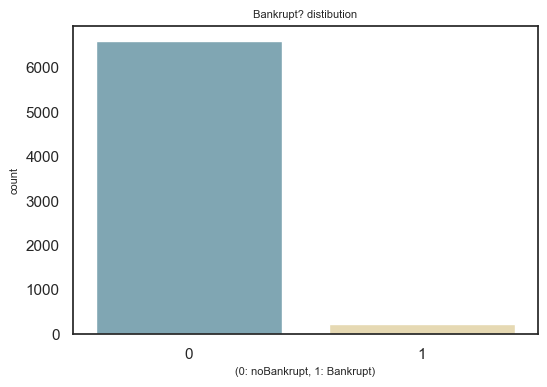

In [78]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Bankrupt', data=data, palette="blend:#7AB,#EDA")

plt.title('Bankrupt? distibution', fontsize=8)
plt.xlabel('(0: noBankrupt, 1: Bankrupt)', fontsize=8)
plt.ylabel('count', fontsize=8)

plt.show()

Il dataset è sbilanciato, solamente il $\approx$ 3.3% del dataset ha il target = 1 -> il 3.3% delle aziende è andata in bancarotta. 

In [79]:
#pca

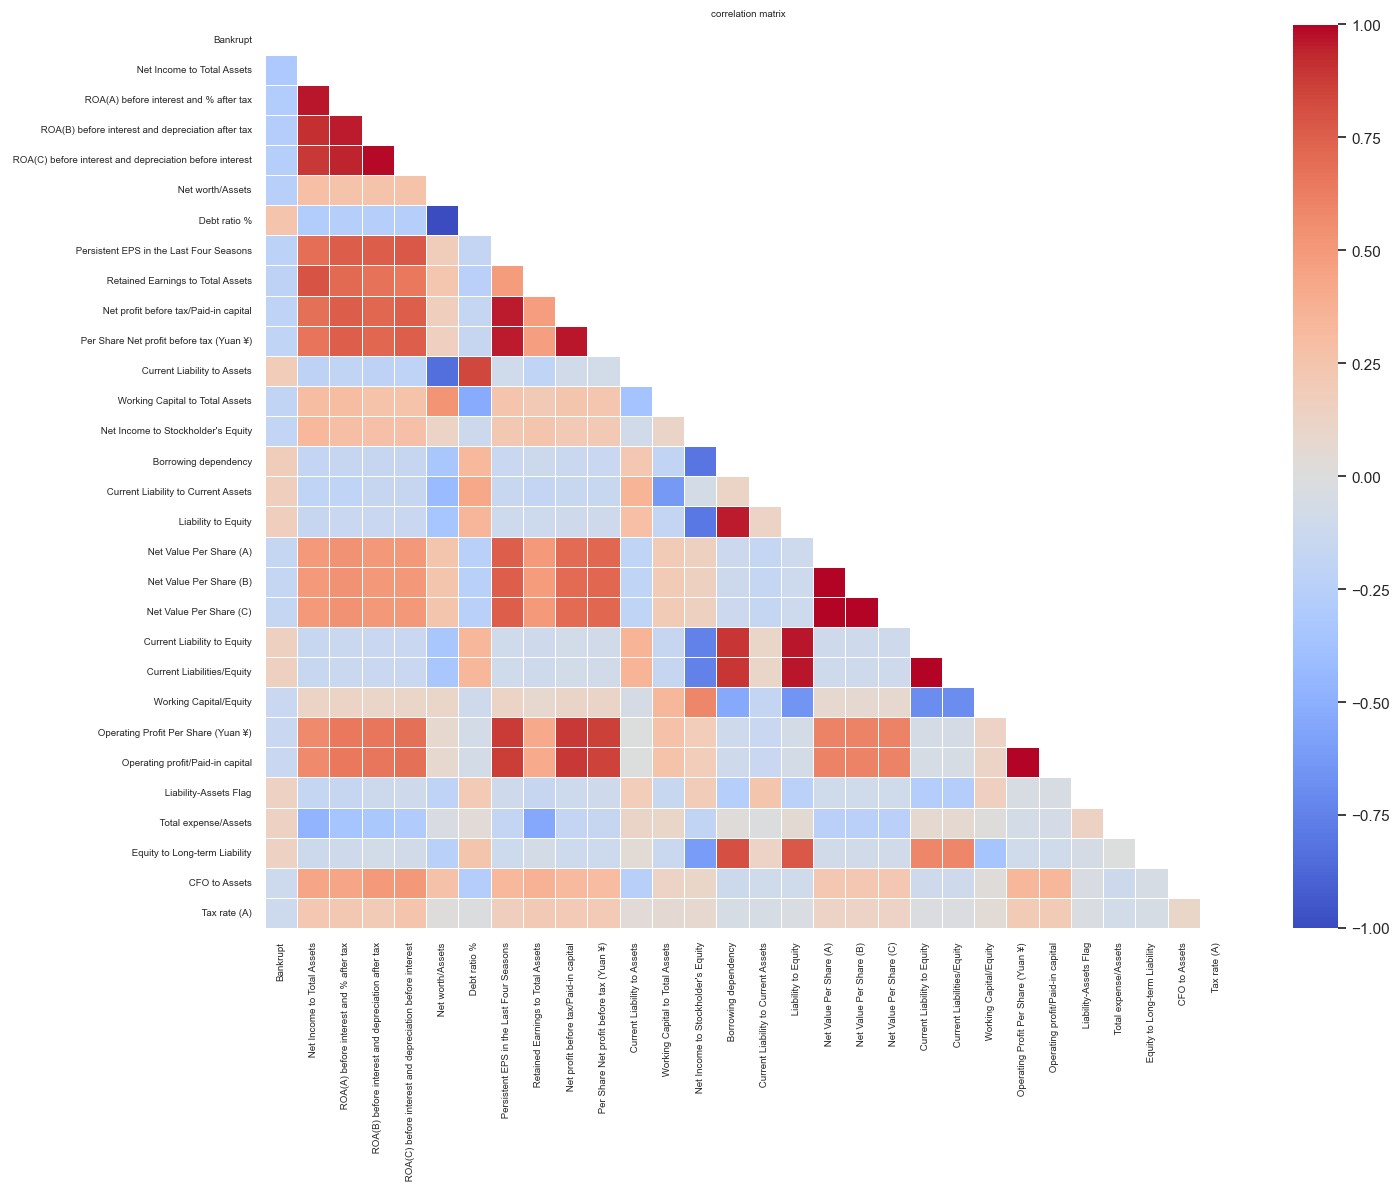

In [80]:
corr = data.corr()
top_corr = corr['Bankrupt'].abs().sort_values(ascending=False).head(30).index

mask = np.triu(np.ones_like(corr.loc[top_corr, top_corr], dtype=bool))
sns.set_theme(style="white")

f, ax = plt.subplots(figsize=(15, 12))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr.loc[top_corr, top_corr], 
            annot=False,            
            cmap='coolwarm',       
            fmt=".1f",
            mask=mask,
            linewidths=0.6
            )
plt.xticks(fontsize=7) 
plt.yticks(fontsize=7)
plt.tight_layout()

plt.title('correlation matrix', fontsize=7)
plt.show()


In [81]:
# data preprocessing 
X = data.drop(['Bankrupt'], axis=1)
y = data['Bankrupt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


Varianza spiegata da ciascuna PC: [0.13860629 0.07303359]
Varianza totale spiegata: 0.21163987698874417


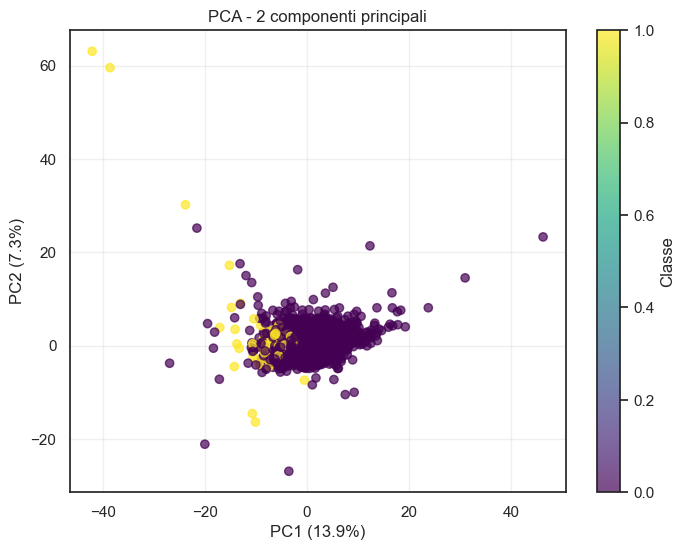

In [82]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# --- 3. Risultati ---
print("Varianza spiegata da ciascuna PC:", pca.explained_variance_ratio_)
print("Varianza totale spiegata:", pca.explained_variance_ratio_.sum())

# --- 4. Visualizzazione ---
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA - 2 componenti principali')
plt.colorbar(label='Classe')
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_pred):.3f}")
print(f"F1-Score:          {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_pred):.3f}")
print("Matrice di Confusione:")
print(confusion_matrix(y_test, y_pred).transpose())

Balanced Accuracy: 0.822
Recall:            0.769
Precision:         0.196
F1-Score:          0.312
ROC-AUC:           0.822
Matrice di Confusione:
[[1722   18]
 [ 246   60]]


/opt/miniconda3/envs/env1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#smote

smote = SMOTE(random_state=42, sampling_strategy='minority')
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()



Bankrupt
0    4631
1    4631
Name: count, dtype: int64

Varianza spiegata da ciascuna PC: [0.22225523 0.15070404]
Varianza totale spiegata: 0.37295927043287225


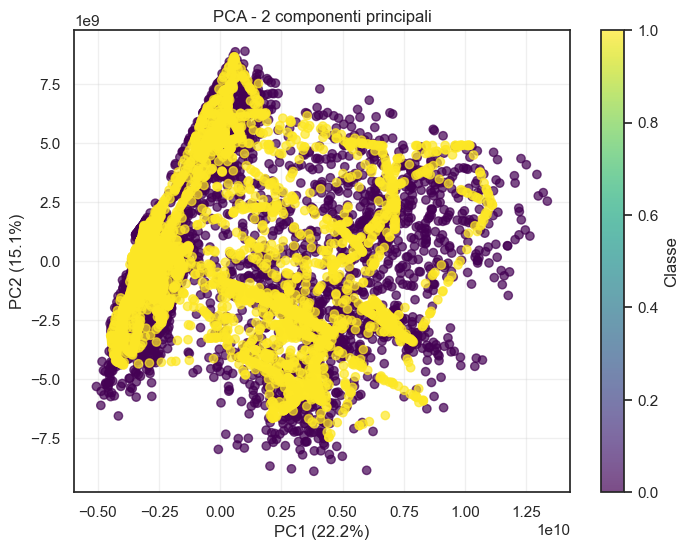

In [88]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_smote)

# --- 3. Risultati ---
print("Varianza spiegata da ciascuna PC:", pca.explained_variance_ratio_)
print("Varianza totale spiegata:", pca.explained_variance_ratio_.sum())

# --- 4. Visualizzazione ---
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_smote, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA - 2 componenti principali')
plt.colorbar(label='Classe')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Verifica il bilanciamento (ora saranno 50% sani e 50% falliti nel train)
print("Distribuzione classi dopo SMOTE nel Train:", y_train_resampled.value_counts())

# 2. Inizializziamo la Regressione Logistica STANDARD (SENZA class_weight='balanced')
model_smote = LogisticRegression(random_state=42) # <--- Niente class_weight qui!

# 3. Fit sui dati bilanciati sinteticamente dallo SMOTE
model_smote.fit(X_train_resampled, y_train_resampled)

# 4. Predizione sul Test Set originale scalato (il Test Set non va MAI toccato dallo SMOTE!)
y_pred_smote = model_smote.predict(X_test_scaled)

# --- 5. Risultati e Metriche ---
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_smote):.3f}")
print(f"Recall:            {recall_score(y_test, y_pred_smote):.3f}")
print(f"Precision:         {precision_score(y_test, y_pred_smote):.3f}")
print(f"F1-Score:          {f1_score(y_test, y_pred_smote):.3f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_pred_smote):.3f}")

print("\nMatrice di Confusione con SMOTE:")
print(confusion_matrix(y_test, y_pred_smote))

#print(f'\u03B20 and \u03B21 are {model_smote.intercept_} and {model_smote.coef_}')

Distribuzione classi dopo SMOTE nel Train: Bankrupt
0    4631
1    4631
Name: count, dtype: int64
Balanced Accuracy: 0.798
Recall:            0.718
Precision:         0.190
F1-Score:          0.300
ROC-AUC:           0.798

Matrice di Confusione con SMOTE:
[[1729  239]
 [  22   56]]
β0 and β1 are [-4.42433962] and [[-5.29271734e-01  1.08853765e+00 -2.66017512e-01 -1.22500700e-02
   2.40591440e-01  1.82701128e+00  7.92706231e-01  6.28052808e-02
  -8.86431784e-01  1.91650959e-02 -6.56847934e-02  7.51031287e-03
  -2.09002936e+00  5.94521379e-02 -1.44812092e-02 -1.63227461e+00
   3.82221443e-01  8.66152133e-01 -2.37037325e+00  2.60000946e-01
  -7.38194131e-01  9.58284960e-01 -6.87290502e-03 -9.25716282e-01
  -2.11582069e-01 -3.94126133e-01  5.96377599e-01  4.62005868e-02
  -5.60154682e-03 -1.34695017e-01  1.17912095e-01  2.99859630e-01
  -3.68823743e+00 -9.87575878e-02 -4.12257288e-02  1.14784278e+00
   8.95077928e-01 -8.95077928e-01  1.58119092e-01  1.03700226e+00
   1.12630986e-01  1.561

/opt/miniconda3/envs/env1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
